In [1]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.0 MB/s eta 0:00:00


In [20]:
!yt-dlp -f "best[height<=720][ext=mp4]" \
        --recode-video mp4 \
        --postprocessor-args "ffmpeg:-c:v libx264 -preset fast -crf 23" \
        "https://www.youtube.com/shorts/O1jV3MZTmjo" \
        -o "/content/fixed_output.mp4"

[youtube] Extracting URL: https://www.youtube.com/shorts/O1jV3MZTmjo
[youtube] O1jV3MZTmjo: Downloading webpage
[youtube] O1jV3MZTmjo: Downloading android vr player API JSON
[info] O1jV3MZTmjo: Downloading 1 format(s): 18
[download] Destination: /content/fixed_output.mp4
[download] 100% of    5.25MiB in 00:00:00 at 6.42MiB/s
[VideoConvertor] Not converting media file "/content/fixed_output.mp4"; already is in target format mp4


## Video Link: <https://www.youtube.com/shorts/O1jV3MZTmjo>

In [21]:
from IPython.display import Video

Video("./fixed_output.mp4")

### Turning on Expandable Segments, a PyTorch setting to allow it to use the GPU's memory in a dynamic fashion

In [3]:
!pip -q install transformers accelerate opencv-python pillow

import os

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [6]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [4]:
import cv2
import gc
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "HuggingFaceTB/SmolVLM-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)

model

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(729, 1152)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-26): 27 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_feature

### Seeing the device of the model to ensure that it loads on the GPU

In [5]:
model.device

device(type='cuda', index=0)

### Frame extraction logic

Take all the frame count, and then take the evenly spaced samples of the entire video for inference.

In [ ]:
VIDEO_PATH = "/content/fixed_output.mp4"

import numpy as np

def extract_frames(video_path, max_frames=8, resize=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    print(f"Video FPS: {fps}, total frames: {total_frames}, duration: {total_frames/fps:.2f}s")

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read total frame count.")

    n_samples = min(max_frames, total_frames)
    target_indices = set(np.linspace(0, total_frames - 1, n_samples, dtype=int).tolist())

    frames = []
    timestamps = []
    frame_idx = 0
    frame_printed = False

    while True:
        ret, frame = cap.read()
        if not ret:
            print(f"Frame? {ret}")
            break

        if frame_idx in target_indices:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(rgb)
            if not frame_printed:
                frame_printed = True
                print(f"Frame original size: {img.size}")
            if resize is not None:
                img = img.resize(resize)

            frames.append(img)
            timestamps.append(frame_idx / fps)

            if len(frames) == n_samples:
                break

        frame_idx += 1

    cap.release()
    return frames, timestamps

frames, timestamps = extract_frames(VIDEO_PATH, max_frames=8, resize=(360, 640))
print(f"Extracted {len(frames)} frames\ntimestamps: {timestamps}")

Video FPS: 30.0, total frames: 2214, duration: 73.80s
Frame original size: (360, 640)
Extracted 8 frames
timestamps: [0.0, 10.533333333333333, 21.066666666666666, 31.6, 42.13333333333333, 52.666666666666664, 63.2, 73.76666666666667]


In [48]:
len(frames)

8

### Visualizing the frames extracted

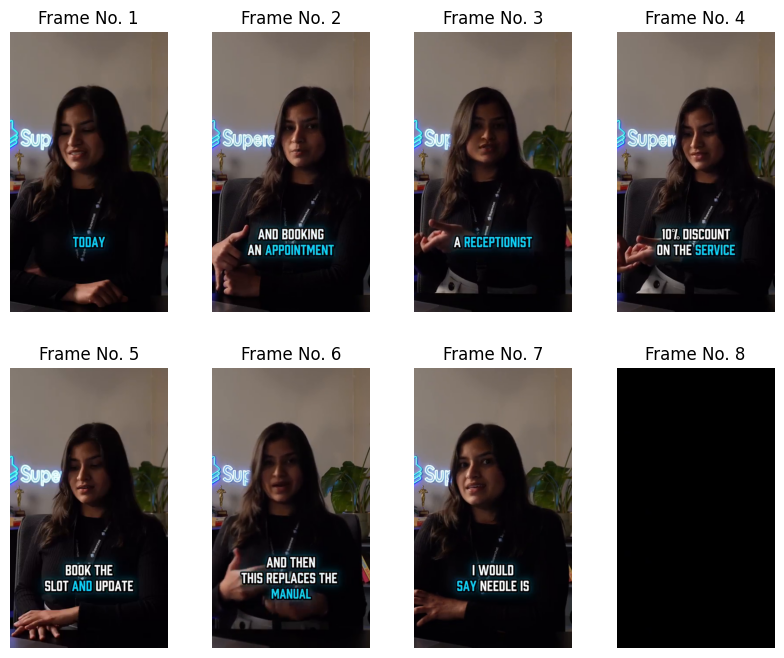

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 8), nrows=2, ncols=4)
for i, a in zip(np.arange(1, 13), ax.flatten()):
    a.set_title(f"Frame No. {i}")
    a.imshow(frames[i-1])
    a.axis('off')
plt.show()

In [57]:
# SmolVLM multi-image prompt for video captioning
messages = [{
    "role": "user",
    "content": [
        {"type": "image"} for _ in frames
    ] + [{
        "type": "text",
        "text": "These images are sequential frames from the same video, shown in chronological order. Describe what happens across the entire video clip in 2-3 sentences, focusing on actions, motion, and scene changes."
    }]
}]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=frames, return_tensors="pt").to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.6,
    )
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Done")

Done


In [58]:
caption

'User:<row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_co

### Final output :)

In [59]:
from IPython.display import Markdown, display_markdown

display_markdown(Markdown(f'## {caption.split("\nAssistant:")[-1][1:]}'))

## In the first frame, the woman is sitting on the chair in front of the Superchat logo. In the second frame, the woman is standing in front of the Superchat logo. In the third frame, the woman is sitting on the chair in front of the Superchat logo. In the fourth frame, the woman is standing in front of the Superchat logo.